NEW CODE 

UPDATED CODE

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import json
import matplotlib.pyplot as plt

# MEMORY + STABILITY SETTINGS (VERY IMPORTANT)
IMG_SIZE = (160, 160)   # Smaller = no kernel crash
BATCH_SIZE = 16         # DO NOT use 32 for PlantVillage
EPOCHS_PHASE1 = 25
EPOCHS_PHASE2 = 20

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

2026-02-21 15:36:53.879413: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771688214.066420      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771688214.116412      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771688214.584267      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771688214.584319      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771688214.584322      55 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
DATASET_PATH = "/kaggle/input/plantvillage-dataset/color"
# If your path is different, change accordingly

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Classes:", class_names[:5], "...")

Found 54305 files belonging to 38 classes.
Using 43444 files for training.


I0000 00:00:1771688255.308828      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Number of classes: 38
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy'] ...


In [4]:
with open("class_names_f.json", "w") as f:
    json.dump(class_names, f)

print("class_names.json saved ✅")

class_names.json saved ✅


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

# DO NOT USE .cache() (causes Kaggle kernel crash)
train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

print("Dataset pipeline optimized ✅")

Dataset pipeline optimized ✅


In [6]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [7]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # 🔥 PHASE 1: Freeze backbone
print("MobileNetV2 Loaded Successfully ✅")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
MobileNetV2 Loaded Successfully ✅


In [8]:
inputs = keras.Input(shape=(160, 160, 3))

# Augmentation
x = data_augmentation(inputs)

# 🔥 VERY IMPORTANT (Most students miss this)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

# Feature extraction
x = base_model(x, training=False)

# Classification head
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,431,974 (9.28 MB)

 Trainable params: 171,430 (669.65 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [9]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [10]:
print("🔥 Phase 1: Training classifier head ONLY")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    callbacks=[early_stop, reduce_lr]
)

🔥 Phase 1: Training classifier head ONLY
Epoch 1/25


I0000 00:00:1771688303.879034     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


2716/2716 ━━━━━━━━━━━━━━━━━━━━ 121s 31ms/step - accuracy: 0.4979 - loss: 1.9805 - val_accuracy: 0.8670 - val_loss: 0.4586 - learning_rate: 1.0000e-04
Epoch 2/25
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 65s 21ms/step - accuracy: 0.8031 - loss: 0.6575 - val_accuracy: 0.8969 - val_loss: 0.3338 - learning_rate: 1.0000e-04
Epoch 3/25
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 65s 21ms/step - accuracy: 0.8495 - loss: 0.4850 - val_accuracy: 0.9086 - val_loss: 0.2816 - learning_rate: 1.0000e-04
Epoch 4/25
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 65s 21ms/step - accuracy: 0.8716 - loss: 0.4162 - val_accuracy: 0.9153 - val_loss: 0.2691 - learning_rate: 1.0000e-04
Epoch 5/25
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 64s 21ms/step - accuracy: 0.8829 - loss: 0.3732 - val_accuracy: 0.9212 - val_loss: 0.2424 - learning_rate: 1.0000e-04
Epoch 6/25
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 65s 21ms/step - accuracy: 0.8916 - loss: 0.3507 - val_accuracy: 0.9220 - val_loss: 0.2378 - learning_rate: 1.0000e-04
Epoch 7/25
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 65s 21ms

In [11]:
print("🚀 Phase 2: Fine-tuning top layers")

base_model.trainable = True

# Freeze most layers, unfreeze top layers only
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # Lower LR for fine-tuning
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    callbacks=[early_stop, reduce_lr]
)

🚀 Phase 2: Fine-tuning top layers
Epoch 1/20
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 113s 35ms/step - accuracy: 0.8110 - loss: 0.6417 - val_accuracy: 0.9304 - val_loss: 0.2121 - learning_rate: 1.0000e-05
Epoch 2/20
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 99s 34ms/step - accuracy: 0.8959 - loss: 0.3288 - val_accuracy: 0.9490 - val_loss: 0.1510 - learning_rate: 1.0000e-05
Epoch 3/20
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 99s 34ms/step - accuracy: 0.9137 - loss: 0.2657 - val_accuracy: 0.9574 - val_loss: 0.1321 - learning_rate: 1.0000e-05
Epoch 4/20
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 99s 34ms/step - accuracy: 0.9275 - loss: 0.2287 - val_accuracy: 0.9603 - val_loss: 0.1248 - learning_rate: 1.0000e-05
Epoch 5/20
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 99s 34ms/step - accuracy: 0.9355 - loss: 0.1945 - val_accuracy: 0.9564 - val_loss: 0.1354 - learning_rate: 1.0000e-05
Epoch 6/20
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 102s 35ms/step - accuracy: 0.9422 - loss: 0.1810 - val_accuracy: 0.9649 - val_loss: 0.1093 - learning_rate: 1.0000e-05
Epoc

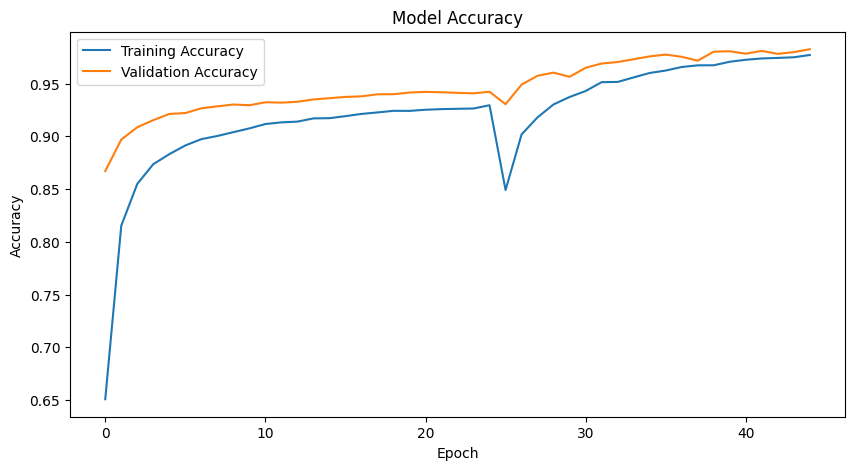

In [12]:
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

plt.figure(figsize=(10,5))
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [13]:
model.save("plant_disease_model_f.keras")

print("Model saved as plant_disease_model.keras ✅")

Model saved as plant_disease_model.keras ✅
